In [64]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import numpy as np
import matplotlib.pyplot as plt
import os
import random

In [65]:

# 1. CARGAR DATASET
df = pd.read_csv("dataset.csv", sep=",")

# Seleccionar
select_letras = df['image'].str.contains('Dataset_Letras', case=False, na=False)
select_palabras = df['image'].str.contains('Dataset_Palabras', case=False, na=False)
select_oraciones = df['image'].str.contains('Dataset_Oraciones', case=False, na=False)

# Filtrar los DataFrames
df_letras = df[select_letras]
df_palabras = df[select_palabras]
df_oraciones = df[select_oraciones]

# 3. DIVIDIR CADA SUBSET EN TRAIN/VAL

# Letras: 93.3% train, 6.7% val
X1_train, X1_val, y1_train, y1_val = train_test_split(
    df_letras['image'].values,
    df_letras['label'].values,
    test_size=0.067,
    random_state=42,
    shuffle=True
)

# Palabras: 93.3% train, 6.7% val
X2_train, X2_val, y2_train, y2_val = train_test_split(
    df_palabras['image'].values,
    df_palabras['label'].values,
    test_size=0.067,
    random_state=42,
    shuffle=True
)

# Oraciones: 93.4% train, 6.6% val
X3_train, X3_val, y3_train, y3_val = train_test_split(
    df_oraciones['image'].values,
    df_oraciones['label'].values,
    test_size=0.066,
    random_state=42,
    shuffle=True
)

# Concatenar arrays de numpy
X_train = np.concatenate([X1_train, X2_train, X3_train])
y_train = np.concatenate([y1_train, y2_train, y3_train])

X_val = np.concatenate([X1_val, X2_val, X3_val])
y_val = np.concatenate([y1_val, y2_val, y3_val])

# 5. MEZCLAR EL DATASET FINAL (IMPORTANTE)

# Crear índices aleatorios
train_indices = np.random.permutation(len(X_train))
val_indices = np.random.permutation(len(X_val))

# Reordenar
X_train = X_train[train_indices]
y_train = y_train[train_indices]

X_val = X_val[val_indices]
y_val = y_val[val_indices]



In [ ]:
# --- collate_fn corregido ---
def collate_fn(batch):
    # Ordenar por ancho (recomendado)
    batch.sort(key=lambda x: x[0].shape[-1], reverse=True)

    images = [b[0] for b in batch]
    labels = [b[1] for b in batch]
    lengths = [b[2] for b in batch]

    max_width = max(img.shape[-1] for img in images)
    batch_size = len(images)
    img_height = images[0].shape[-2]
    padded = torch.zeros(batch_size, 1, img_height, max_width)

    for i, img in enumerate(images):
        w = img.shape[-1]
        padded[i, :, :, :w] = img

    concat_labels = torch.cat(labels)
    lengths = torch.tensor(lengths, dtype=torch.int32)

    return padded, concat_labels, lengths


In [67]:
# --- Dataset adaptado a imágenes ---
# PARTE 1: CARGA DE DATOS

class CargarDataset(Dataset):
    def __init__(self, X, y, alphabet, img_height=32, max_width=256):
        self.X = X  # rutas completas
        self.y = y  # textos
        self.img_height = img_height
        self.max_width = max_width
        self.alphabet = alphabet

        # Mapa carácter → índice
        self.char_to_idx = {char: i+1 for i, char in enumerate(alphabet)}
        self.idx_to_char = {i+1: char for i, char in enumerate(alphabet)}

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        img_path = self.X[idx]
        text = self.y[idx]

        # --- Cargar imagen ---
        img = Image.open(img_path).convert("L")

        w, h = img.size
        new_width = int(w * self.img_height / h)
        new_width = min(new_width, self.max_width)

        img = img.resize((new_width, self.img_height), Image.LANCZOS)

        img_array = np.array(img, dtype=np.float32) / 255.0
        img_tensor = torch.FloatTensor(img_array).unsqueeze(0)  # (1,H,W)

        # --- Codificar texto ---
        label = [self.char_to_idx[c] for c in text if c in self.char_to_idx]
        label_tensor = torch.LongTensor(label)

        return img_tensor, label_tensor, len(label_tensor)


alphabet = "abcdefghijklmnñopqrstuvwxyz0123456789., "

dataset = {
    "train": CargarDataset(X_train, y_train, alphabet),
    "val": CargarDataset(X_val, y_val, alphabet)
}

dataloader = {
    "train": DataLoader(dataset["train"], batch_size=32, shuffle=True, collate_fn=collate_fn),
    "val": DataLoader(dataset["val"], batch_size=16, shuffle=False, collate_fn=collate_fn)
}


In [68]:
# --- Función softmax ---
def softmax(x):
    return torch.exp(x) / torch.exp(x).sum(axis=-1, keepdims=True)


In [ ]:
# --- SimpleCNN corregido para CTC ---
class SimpleCNN(nn.Module):
    def __init__(self, num_classes):
        super(SimpleCNN, self).__init__()

        self.cnn = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2,2),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2,2),
            nn.Conv2d(64, 128, 3, padding=1), nn.ReLU()
        )

        self.fc = nn.Sequential(
            nn.Linear(128, 256), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(256, 128), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        # CNN
        x = self.cnn(x)  # (batch, 128, H, W)

        # Adaptative pooling para preservar información vertical
        x = nn.functional.adaptive_avg_pool2d(x, (1, x.size(3)))  # (batch, 128, 1, W)
        x = x.squeeze(2)  # (batch, 128, W)
        x = x.permute(2, 0, 1)  # (seq_len=W, batch, features=128)

        # Pasar por capa final
        x = self.fc(x)  # (seq_len, batch, num_classes)
        return x


In [70]:
# --- ENTRENAMIENTO ADAPTADO A CTC (respeta tu formato) ---
def fit(model, dataloader, epochs=200, log_each=10, weight_decay=1e-4, early_stopping=20):

    # 🔧 CAMBIO AQUÍ: CrossEntropy → CTCLoss
    criterion = nn.CTCLoss(blank=0, zero_infinity=True)

    optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=weight_decay)

    l, acc, val_l, val_acc = [], [], [], []
    best_acc, step = 0, 0

    for e in range(1, epochs+1):

        # ----- ENTRENAMIENTO -----
        model.train()
        _l, _acc = [], []

        for x_b, y_b, y_len in dataloader["train"]:

            # CAMBIO AQUÍ: obtener output CRNN (seq_len, batch, clases)
            outputs = model(x_b)

            # CAMBIO AQUÍ: input_lengths depende del ancho del output
            seq_len = outputs.size(0)
            batch_size = outputs.size(1)
            input_lengths = torch.full(size=(batch_size,), fill_value=seq_len, dtype=torch.int32)

            # CTC Loss
            loss = criterion(outputs.log_softmax(2), y_b, input_lengths, y_len)
            _l.append(loss.item())

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        l.append(np.mean(_l))

        # ----- VALIDACIÓN -----
        model.eval()
        _l = []

        with torch.no_grad():
            for x_b, y_b, y_len in dataloader["val"]:
                outputs = model(x_b)
                seq_len = outputs.size(0)
                batch_size = outputs.size(1)
                input_lengths = torch.full(size=(batch_size,), fill_value=seq_len, dtype=torch.int32)

                loss = criterion(outputs.log_softmax(2), y_b, input_lengths, y_len)
                _l.append(loss.item())

        val_l.append(np.mean(_l))
        val_acc.append(0)  # 🔧 CAMBIO: accuracy no aplica en CTC, se deja 0

        # Guardar mejor modelo
        if val_l[-1] < best_acc or best_acc == 0:
            best_acc = val_l[-1]
            torch.save(model.state_dict(), "ckpt.pt")
            step = 0
            print(f"Mejor modelo guardado en epoch {e}")
        else:
            step += 1

        if early_stopping and step > early_stopping:
            print(f"Early stopping en epoch {e}")
            break

        if not e % log_each:
            print(f"Epoch {e}/{epochs} loss {l[-1]:.5f} val_loss {val_l[-1]:.5f}")

    model.load_state_dict(torch.load("ckpt.pt"))

    return {
        "epoch": list(range(1, len(l)+1)),
        "loss": l,
        "val_loss": val_l
    }


In [71]:
num_classes = len(np.unique(y_train))

model = SimpleCNN(num_classes=num_classes)
history = fit(model, dataloader, epochs=50)

RuntimeError: target_lengths must be of size batch_size

Predicción: e
Real: plastaforma de diferente tamaño y grosor desde 3 , 4 , 5 , 7 , 10 bs
Incorrecto ❌


C:\Users\SAMSUMG\AppData\Local\Temp\ipykernel_6760\2554000655.py:19: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  lengths = torch.tensor(lengths, dtype=torch.int32)


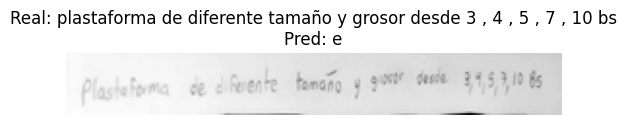

In [ ]:
# --- Seleccionar un batch de validación ---
x_batch, y_batch, y_len = next(iter(dataloader["val"]))
batch_size = x_batch.size(0)

# --- Escoger un índice aleatorio dentro del batch ---
idx = torch.randint(0, batch_size, (1,)).item()
img = x_batch[idx:idx+1]         # imagen seleccionada
target_len = y_len[idx:idx+1]    # longitud del target
target_seq = y_batch[sum(y_len[:idx]):sum(y_len[:idx])+target_len.item()]

# --- Decodificación de la predicción ---
model.eval()
with torch.no_grad():
    output = model(img)
    seq = torch.argmax(output[:,0], dim=1).cpu().numpy()
    text_pred, prev = "", -1
    for i in seq:
        if i != prev and i != 0:
            text_pred += alphabet[i-1]
        prev = i
    text_real = "".join([alphabet[i-1] for i in target_seq.cpu().numpy()])

# --- Mostrar resultado ---
print(f"Predicción: {text_pred}")
print(f"Real: {text_real}")
print("Correcto ✅" if text_pred == text_real else "Incorrecto ❌")

# --- Visualizar imagen ---
plt.imshow(img[0,0].cpu(), cmap='gray')
plt.title(f'Real: {text_real}\nPred: {text_pred}')
plt.axis('off')
plt.show()


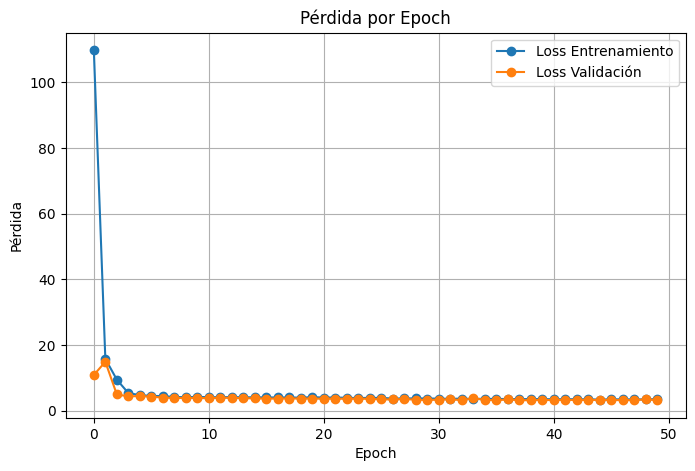

Precisión final de entrenamiento: 346.40%
Precisión final de validación: 316.35%


In [ ]:

# Graficar pérdida
plt.figure(figsize=(8,5))
plt.plot(history['loss'], label='Loss Entrenamiento', marker='o')
plt.plot(history['val_loss'], label='Loss Validación', marker='o')
plt.xlabel('Epoch')
plt.ylabel('Pérdida')
plt.title('Pérdida por Epoch')
plt.legend()
plt.grid(True)
plt.show()

# Mostrar precisión final por print
print(f"Precisión final de entrenamiento: {history['loss'][-1]*100:.2f}%")
print(f"Precisión final de validación: {history['val_loss'][-1]*100:.2f}%")
